In [2]:
#L14 exercise work with gamma rays 

import numpy as np 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import preprocessing


In [3]:
import requests

# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

In [10]:
print(data,names)

[['GRB260421C*' 'GRB260421B' 'GRB260421A' ... 'GRB910424A*' 'GRB910423A*'
  'GRB910421A*']
 ['GRB260421351' 'GRB260421176' 'GRB260421092' ... 'None' 'None' 'None']
 ['8:25:18.055' '4:13:21' '2:12:44' ... '19:43:25.064' '19:51:15.804'
  '9:14:03.800']
 ...
 ['19.2000' '18.1510' '1.5410' ... '3.1360' '208.5760' '5.6960']
 ['True' 'False' 'True' ... 'False' 'False' 'False']
 ['61151.35090341' '61151.17593750' '61151.09217593' ... '48370.82181787'
  '48369.82726625' '48367.38476620']] ['GRB_name' 'GRB_name_Fermi' 'T0' 'ra' 'decl' 'pos_error' 'T90'
 'T90_error' 'T90_start' 'fluence' 'fluence_error' 'redshift' "'T100'"
 'GBM_located' 'mjd_(T0)']


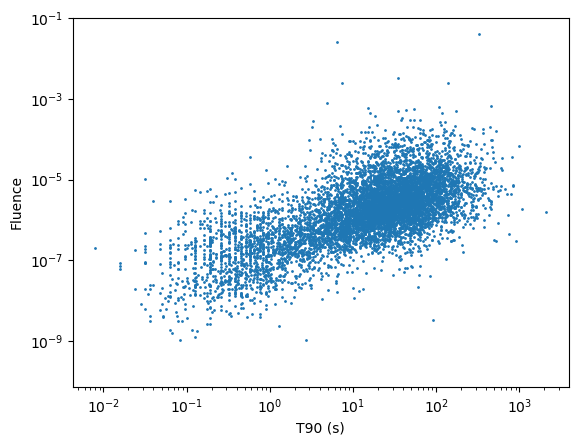

In [22]:
plt.scatter(data[6].astype(float),data[9].astype(float), s=1)
plt.xlabel("T90 (s)")
plt.ylabel("Fluence")
plt.yscale("log")
plt.xscale("log")
plt.show()

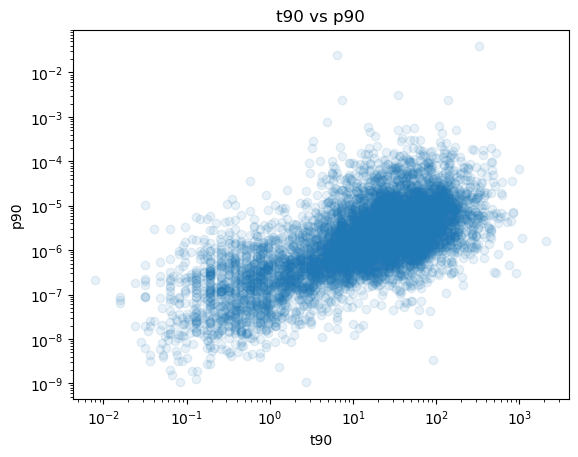

In [48]:
x = data[6].astype(float)
y = data[9].astype(float)

mask = (x > 0.0) & (y > 0.0)

x_masked = x[mask]
y_masked = y[mask]

plt.scatter(x_masked,y_masked,alpha = 0.1)
plt.title("t90 vs p90")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("t90")
plt.ylabel("p90")

plt.show()
        
        
        

In [ ]:
#find if the distribution contain differente sub-populations of GRB

log_x_mask = np.log10(x_masked)
log_y_mask = np.log10(y_masked)
X = np.array([log_x_mask,log_y_mask]).T

clf = KMeans(n_clusters=2)
clf.fit(X)





KMeans(n_clusters=2)

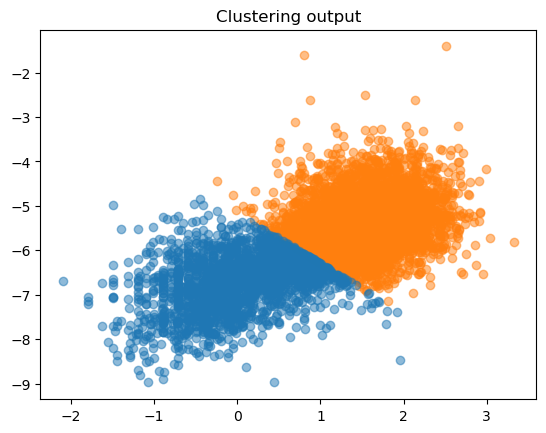

In [59]:
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(X) #labels for each of the points

# plot the data color-coded by cluster id
colors = ['C1', 'C0', 'C2']
for ii in range(3):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], 
                color=colors[ii],alpha=0.5)

# To get some information on these try:
# KMeans?
# help(clf)
plt.title('Clustering output');

In [60]:
print(centers)

[[ 1.52804338 -5.44199729]
 [ 0.0896252  -6.69868827]]
